# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Олійник Божена Орестівна'        
ГРУПА = 'ШІ-33'      
ВАРІАНТ = 7

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 7 · Олійник Божена Орестівна, ШІ-33, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         0        0        5     5   1189
Фанера, м²              4        4        0     1   1189
Фурнітура, компл.       2        4        0     6   1217
Верстат, год            6        3        4     1    915
Лакування, год          2        2        1     0    424

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      20       59       63    41

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Верстат, год
  ціна:   8.0 за одиницю
  обсяг:  до 314 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x₁ — кількість кросел, x₂ — кількість стільців, x₃ — кількість табуретів, x₄ — кількість лав

Цільова функція: Z = 20*x1 + 59*x2 + 63*x3 + 41*x4  →  max

Обмеження:
```
5*x3 + 5*x4 ≤ 1189
4*x1 + 4*x2 + x4 ≤ 1189
2*x1 + 4*x2 + 6*x4 ≤ 1217
6*x1 + 3*x2 + 4*x3 + x4 ≤ 915
2*x1 + 2*x2 + x3 ≤ 424
```

Невід'ємність: x₁, x₂, x₃, x₄ ≥ 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**
Запас ресурсу - параметр, а не змінна, оскільки ми не можемо міняти його значення. Воно задається з самого початку, і не залежить від того, що компанія вирішить виготовляти. Змінні - це значення, які змінюють своє значення в залежності від рішень компнаії.

Якби підприємство мало вплива на кільість запасів (могло їх докупляти), ресурс став би змінною та враховувався б у значення цільової функції, враховувалася б його вартість (віднімалося б bi`*`pi, bi = ціна і ресурсу, pi = кількість купленого і ресурсу)

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0,	114.46,	111.2733333, 126.5266667]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 18950.95333

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 114.46, 111.2733333, 126.5266667] | прибуток 18950.95333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
# ВАШ КОД
n_вир, m_рес = len(c), len(b)

def розвязати(b_вектор, цілі=False):
    r = linprog(-c, A_ub=A, b_ub=b_вектор, bounds=[(0, None)] * n_вир,
                method='highs', integrality=1 if цілі else 0)
    assert r.status == 0, r.message
    x = r.x
    прибуток = -r.fun 
    y = -r.ineqlin.marginals if not цілі else None
    залишок = b_вектор - A @ x
    return x, прибуток, y, залишок

план, прибуток, тіньові, залишок = розвязати(b)

print('Оптимальний план:')
for назва, значення in zip(вироби, план):
    print('  %-8s %10.4f' % (назва, значення))
print('Прибуток: %.4f' % прибуток)

if ПУЛП:
    M = pulp.LpProblem('lab2', pulp.LpMaximize)
    x_p = [pulp.LpVariable('x%d' % (j + 1), lowBound=0) for j in range(n_вир)]
    M += pulp.lpSum(c[j] * x_p[j] for j in range(n_вир))
    for i in range(m_рес):
        M += pulp.lpSum(A[i, j] * x_p[j] for j in range(n_вир)) <= b[i], 'res%d' % i
    M.solve(pulp.PULP_CBC_CMD(msg=0))
    print('PuLP: прибуток %.4f, план %s' % (pulp.value(M.objective),
          [round(v.value(), 4) for v in x_p]))


Оптимальний план:
  Крісло       0.0000
  Стілець    114.4600
  Табурет    111.2733
  Лава       126.5267
Прибуток: 18950.9533
PuLP: прибуток 18950.9533, план [0.0, 114.46, 111.2733, 126.5267]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Дубовий брус, м | 1189 | 0,8133 | 1189 | 715,375 | 369,7353 |
| Фанера, м² | 584,3667 | 0 | 1189 | 1E+30 | 604,6333 |
| Фурнітура, компл. | 1217 | 3,7 | 1217 | 838,0667 | 1144,6 |
| Верстат, год | 915 | 14,7333 | 915 | 157,1375 | 572,3 |
| Лакування, год | 340,1933 | 0 | 424 | 1E+30 | 83,8067 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

В дефіциті: дубовий брус, фурнітура і верстат. Їх залишок = 0, а тіньова ціна 0 не дорвінює. Найдефіцитніший - верстат, оскільки його тіньова ціна найбільша, що означає, що кожна додаткова година дає +14,73 до прибутку.

В надлишку: фанера і лакування. В них не нульовний залишок, а тіньова ціна = 0. Їхнє припустиме збільшення дуууже мале.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 0 | −75,8 | 20 | 75,8 | 1E+30 |
| Стілець | 114,46 | 0 | 59 | 5,0833 | 37 |
| Табурет | 111,2733 | 0 | 63 | 37 | 8,7143 |
| Лава | 126,5267 | 0 | 41 | 110,5 | 7,625 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Не виробляється крісло, його кінцеве значення = 0. Щоб воно увійшло в план, прибуток має зрости хоча б на 75,8 - припустиме збільшення.

Одне крісло споживає 2 фурнітури (2·3,70) і 6 год верстата (6·14,7333), тобто забирає ресурсів на 7,4 + 88,4 = 95,8 — а приносить лише 20. 20 − 95,8 = −75,8 - зменшена вартіст з таблиці.

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
# ВАШ КОД
k = int(np.argmax(тіньові))               
print('Найдорожчий ресурс: %s, тіньова ціна зі звіту = %.4f' % (ресурси[k], тіньові[k]))

b1 = b.copy(); b1[k] += 1
_, прибуток1, _, _ = розвязати(b1)
приріст = прибуток1 - прибуток
print('Прибуток з b+1: %.4f, приріст = %.4f' % (прибуток1, приріст))
print('Збігається з тіньовою ціною:', np.isclose(приріст, тіньові[k], atol=1e-6))

Найдорожчий ресурс: Верстат, год, тіньова ціна зі звіту = 14.7333
Прибуток з b+1: 18965.6867, приріст = 14.7333
Збігається з тіньовою ціною: True


**Відповідь 5.1:** *Найдорожчий ресурс - верстат (тіньова ціна зі звіту 14,7333). Після збільшення запасу з 915 до 916 год прибуток зріс з 18950,9533 до 18965,6867, тобто приріст = 14,7333. Він збігається з тіньовою ціною зі звіту.*

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Останній крок з нахилом = тіньовій ціні: +157 од. (запас 1072)
Перший крок після зламу: 2.0258, далі нахил = 0.0000
Допустиме збільшення зі звіту: 157.1375


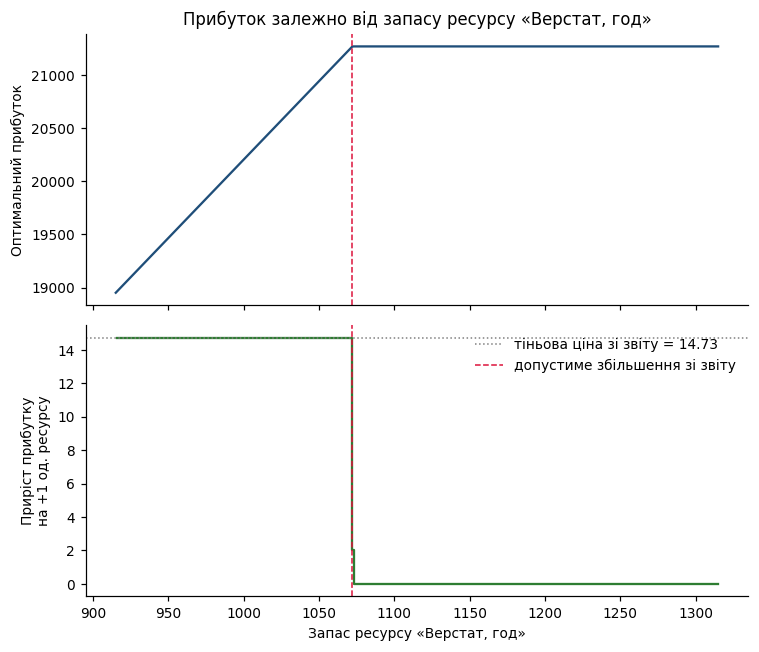

In [8]:
# ВАШ КОД
кроки = np.arange(0, 401)
запаси_k = b[k] + кроки
прибутки = np.array([розвязати(np.where(np.arange(m_рес) == k, b[k] + t, b))[1]
                     for t in кроки])
прирости = np.diff(прибутки)

злам = int(np.argmax(np.abs(прирости - тіньові[k]) > 1e-6))
print('Останній крок з нахилом = тіньовій ціні: +%d од. (запас %d)' % (злам, b[k] + злам))
print('Перший крок після зламу: %.4f, далі нахил = %.4f' % (прирости[злам], прирости[злам + 5]))
допуст_збільшення = 157.1375
print('Допустиме збільшення зі звіту: %.4f' % допуст_збільшення)

fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].plot(запаси_k, прибутки, color='#1f4e79')
ax[0].axvline(b[k] + допуст_збільшення, color='crimson', ls='--', lw=1)
ax[0].set_ylabel('Оптимальний прибуток')
ax[0].set_title('Прибуток залежно від запасу ресурсу «%s»' % ресурси[k])
ax[1].step(запаси_k[1:], прирости, where='pre', color='#2e7d32')
ax[1].axhline(тіньові[k], color='grey', ls=':', lw=1, label='тіньова ціна зі звіту = %.2f' % тіньові[k])
ax[1].axvline(b[k] + допуст_збільшення, color='crimson', ls='--', lw=1,
              label='допустиме збільшення зі звіту')
ax[1].set_ylabel('Приріст прибутку\nна +1 од. ресурсу')
ax[1].set_xlabel('Запас ресурсу «%s»' % ресурси[k])
ax[1].legend(loc='upper right', frameon=False)
plt.tight_layout(); plt.show()

**Відповідь 5.2:** Приріст лишається рівним 14,7333 (горизонтальна лінія на нижньому графіку) до запасу 915 + 157 = 1072 год, тобто на 157 одиниць. Точне значення з обчислення на базисі і зі звіту Excel — 157,1375 збігається з експериментом.

Межа така, оскільки при зростанні запасу верстата дедалі більше виробів випускається, і при +157,1375 год вичерпується залишок лакування (83,81 год): він стає новим зв'язним обмеженням. Після цього базис змінюється, і додаткові години верстата вже не можна перетворити на прибуток (нахил падає до 0). Тому тіньова ціна 14,73 діє лише в діапазоні [915 − 572,3; 915 + 157,1375].

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
# ВАШ КОД
кр = V['ресурс_пропозиції']; ціна = V['ціна_пропозиції']; обсяг = V['обсяг_пропозиції']
print('Пропозиція: %s, ціна %.1f, до %d од.' % (ресурси[кр], ціна, обсяг))
print('Тіньова ціна ресурсу: %.4f' % тіньові[кр])
print('Брати? тіньова ціна %s ціни - %s' %
      ('>' if тіньові[кр] > ціна else '<=', 'так' if тіньові[кр] > ціна else 'ні'))

межа = 157.1375
кількість = int(np.floor(min(обсяг, межа)))
print('Пропонують %d, тіньова ціна діє лише до +%.4f - беремо %d' % (обсяг, межа, кількість))

def чистий_виграш(q):
    bb = b.copy(); bb[кр] += q
    return розвязати(bb)[1] - прибуток - ціна * q

очікуваний = (тіньові[кр] - ціна) * кількість
print('Очікуваний виграш (тіньова ціна - ціна) * q = %.2f' % очікуваний)
print('Розв’язок з новим запасом: %.2f' % чистий_виграш(кількість))
print('Якщо взяти весь обсяг (%d): %.2f' % (обсяг, чистий_виграш(обсяг)))

qs = np.arange(0, обсяг + 1)
вигр = np.array([чистий_виграш(q) for q in qs])
print('Найкраще q за повним скануванням: %d (виграш %.2f)' % (qs[np.argmax(вигр)], вигр.max()))

Пропозиція: Верстат, год, ціна 8.0, до 314 од.
Тіньова ціна ресурсу: 14.7333
Брати? тіньова ціна > ціни - так
Пропонують 314, тіньова ціна діє лише до +157.1375 - беремо 157
Очікуваний виграш (тіньова ціна - ціна) * q = 1057.13
Розв’язок з новим запасом: 1057.13
Якщо взяти весь обсяг (314): -196.84
Найкраще q за повним скануванням: 157 (виграш 1057.13)


**Відповідь 6.1:**

* Брати чи ні і чому: брати, верстат за 8,0 за годину, а тіньова ціна верстата 14,7333 > 8,0. Кожна куплена година приносить 14,73, а коштує 8,00, тобто чистий +6,73 на годину.
* Скільки одиниць має сенс купити і чому не більше: 157 год з 314 пропонованих. Тіньова ціна 14,73 діє лише до допустимого збільшення 157,1375, далі вичерпується лакування і  додаткові години верстата вже нічого не дають (приріст ≈ 0), а платити за них доводиться по 8,0.
* Очікуваний виграш: (14,7333 − 8,0) · 157 = 1057,13
* Перевірка прямим розв'язанням дала: новий прибуток - витрати на закупівлю = 1057,13 — збіг з розрахунком.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
# ВАШ КОД
ненульових = int(np.sum(план > 1e-6))
звязних = int(np.sum(залишок < 1e-6))
print('ненульові:', [(вироби[j], round(план[j], 2)) for j in range(n_вир) if план[j] > 1e-6])
print('зв’язні:  ', [ресурси[i] for i in range(m_рес) if залишок[i] < 1e-6])

ненульові: [('Стілець', np.float64(114.46)), ('Табурет', np.float64(111.27)), ('Лава', np.float64(126.53))]
зв’язні:   ['Дубовий брус, м', 'Фурнітура, компл.', 'Верстат, год']


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 3 | зв’язних обмежень: 3
Етап 7 пройдено


**Відповідь 7.1:** *Числа збіглись. Якби була б розбіжніст це свідчило б або про вироджений розв'язок (одна з базисних змінних = 0), якщо ненульових значень менше ніж звєязних, або про те, що розв'язок не є вершною, якщо ненульових більше ніж зв'язних.*

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
# ВАШ КОД
x_lp, p_lp = план, прибуток

x_ok = np.round(план)
витрати_ok = A @ x_ok
допустимий_ok = bool(np.all(витрати_ok <= b + 1e-9))
p_ok = c @ x_ok
print('Округлений план:', x_ok, '| прибуток за формулою = %.0f' % p_ok)
print('Витрати ресурсів:', витрати_ok, '\nЗапаси:          ', b)
for i in range(m_рес):
    if витрати_ok[i] > b[i]:
        print('  ПОРУШЕНО: %s — потрібно %.0f, є %.0f' % (ресурси[i], витрати_ok[i], b[i]))
print('Допустимий:', допустимий_ok)

x_fl = np.floor(план)
print('Округлення донизу:', x_fl,'| прибуток %.0f' % (c @ x_fl), '| допустимий:', bool(np.all(A @ x_fl <= b)))

x_int, p_int, _, _ = розвязати(b, цілі=True)
x_int = np.round(x_int)
print('Цілочисельний оптимум:', x_int, '| прибуток %.0f' % p_int,
      '| допустимий:', bool(np.all(A @ x_int <= b + 1e-9)))
print('Втрата відносно LP: %.2f (%.4f%%)' % (p_lp - p_int, 100 * (p_lp - p_int) / p_lp))

Округлений план: [  0. 114. 111. 127.] | прибуток за формулою = 18926
Витрати ресурсів: [1190.  583. 1218.  913.  339.] 
Запаси:           [1189. 1189. 1217.  915.  424.]
  ПОРУШЕНО: Дубовий брус, м — потрібно 1190, є 1189
  ПОРУШЕНО: Фурнітура, компл. — потрібно 1218, є 1217
Допустимий: False
Округлення донизу: [  0. 114. 111. 126.] | прибуток 18885 | допустимий: True
Цілочисельний оптимум: [  0. 115. 111. 126.] | прибуток 18944 | допустимий: True
Втрата відносно LP: 6.95 (0.0367%)


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 0; 114,46; 111,2733; 126,5267 | 18950,95 | так |
| округлений | 0; 114; 111; 127 | 18926 | ні |
| цілочисельний оптимум | 0; 115; 111; 126 | 18944 | так |

**Висновок:** *Просто округлювати не можна. Округлений план потребує 1190 м дубового бруса при запасі 1189 і 1218 компл. фурнітури при запасі 1217 — тобто порушує обмеження двох дефіцитних ресурсів.
Округлення донизу допустиме, але дає лише 18885. 
Справжній цілочисельний оптимум дає 18944. Він поступається LP-розв'язку на 6,95, але відрізняється від нього не кожне число на 0,5, а іншою комбінацією (стілець +1 відносно округлення донизу, лава без змін).
Тому цілочисельну задачу треба розв'язувати як таку.*


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Одеса', 'Львів', 'Івано-Франківськ']
споживачі     = ['Біла Церква', 'Овруч', 'Житомир', 'Ніжин']
D = np.array([[400, 690, 560, 610],
              [480, 430, 320, 610],
              [510, 570, 370, 680]],
             dtype=float)
запас = [37, 41, 22]
попит = [19, 26, 31, 24]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Біла Церква,Овруч,Житомир,Ніжин
Одеса,400.0,690.0,560.0,610.0
Львів,480.0,430.0,320.0,610.0
Івано-Франківськ,510.0,570.0,370.0,680.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [22]:
# ВАШ КОД — розв'язок 1
m_т, n_т = D.shape

T1 = pulp.LpProblem('transport_pulp', pulp.LpMinimize)
x1 = [[pulp.LpVariable('x_%d_%d' % (i, j), lowBound=0) for j in range(n_т)] for i in range(m_т)]
T1 += pulp.lpSum(D[i, j] * x1[i][j] for i in range(m_т) for j in range(n_т))
for i in range(m_т):
    T1 += pulp.lpSum(x1[i][j] for j in range(n_т)) == запас[i], 'запас_%d' % i
for j in range(n_т):
    T1 += pulp.lpSum(x1[i][j] for i in range(m_т)) == попит[j], 'попит_%d' % j
T1.solve(pulp.PULP_CBC_CMD(msg=0))
assert pulp.LpStatus[T1.status] == 'Optimal'

план1 = np.array([[x1[i][j].value() for j in range(n_т)] for i in range(m_т)])
вартість1 = pulp.value(T1.objective)
тіньові1 = np.array([T1.constraints['запас_%d' % i].pi for i in range(m_т)] +
                    [T1.constraints['попит_%d' % j].pi for j in range(n_т)])

print('PuLP (CBC): вартість = %.1f ткм' % вартість1)
print(pd.DataFrame(план1, index=постачальники, columns=споживачі).round(2).to_string())
print('Тіньові ціни (постачальники | споживачі):')
print('  ', np.round(тіньові1[:m_т], 4), '|', np.round(тіньові1[m_т:], 4))

PuLP (CBC): вартість = 44440.0 ткм
                  Біла Церква  Овруч  Житомир  Ніжин
Одеса                    19.0    0.0      0.0   18.0
Львів                     0.0   26.0      9.0    6.0
Івано-Франківськ          0.0    0.0     22.0    0.0
Тіньові ціни (постачальники | споживачі):
   [320. 320. 370.] | [ 80. 110.   0. 290.]


In [15]:
# ВАШ КОД — розв'язок 2
A_eq = np.zeros((m_т + n_т, m_т * n_т))
for i in range(m_т):
    A_eq[i, i * n_т:(i + 1) * n_т] = 1
for j in range(n_т):
    A_eq[m_т + j, j::n_т] = 1
b_eq = np.array(list(запас) + list(попит), float)

r2 = linprog(D.ravel(), A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
assert r2.status == 0, r2.message
план2 = r2.x.reshape(m_т, n_т)
вартість2 = r2.fun
тіньові2 = r2.eqlin.marginals

print('linprog (HiGHS): вартість = %.1f ткм' % вартість2)
print(pd.DataFrame(план2, index=постачальники, columns=споживачі).round(2).to_string())
print('Тіньові ціни (постачальники | споживачі):')
print('  ', np.round(тіньові2[:m_т], 4), '|', np.round(тіньові2[m_т:], 4))

linprog (HiGHS): вартість = 44440.0 ткм
                  Біла Церква  Овруч  Житомир  Ніжин
Одеса                    19.0    0.0      0.0   18.0
Львів                     0.0   26.0      9.0    6.0
Івано-Франківськ          0.0    0.0     22.0    0.0
Тіньові ціни (постачальники | споживачі):
   [-0. -0. 50.] | [400. 430. 320. 610.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [ ]:
# ВАШ КОД
print('Вартість: PuLP %.1f | linprog %.1f | різниця %.2e' % (вартість1, вартість2, вартість1 - вартість2))
print('Плани перевезень однакові:', np.allclose(план1, план2, atol=1e-6))

табл = pd.DataFrame({'PuLP': тіньові1, 'linprog': тіньові2, 'різниця (PuLP − linprog)': тіньові1 - тіньові2},
                    index=['запас: ' + p for p in постачальники] + ['попит: ' + s for s in споживачі])
print(); print(табл.round(4).to_string())

різн = тіньові1 - тіньові2
різн_п, різн_с = різн[:m_т], різн[m_т:]
print()
print('різниці для постачальників:', np.round(різн_п, 6), '| усі однакові:', np.allclose(різн_п, різн_п[0]))
print('різниці для споживачів:    ', np.round(різн_с, 6), '| усі однакові:', np.allclose(різн_с, різн_с[0]))
print('сума різниць постачальник + споживач = %.6f' % (різн_п[0] + різн_с[0]))

print('\nu_i + v_j  (PuLP)   :\n', np.round(тіньові1[:m_т, None] + тіньові1[None, m_т:], 3))
print('u_i + v_j  (linprog):\n', np.round(тіньові2[:m_т, None] + тіньові2[None, m_т:], 3))
print('Збігаються:', np.allclose(тіньові1[:m_т, None] + тіньові1[None, m_т:],
                                  тіньові2[:m_т, None] + тіньові2[None, m_т:]))

Вартість: PuLP 44440.0 | linprog 44440.0 | різниця 0.00e+00
Плани перевезень однакові: True

                          PuLP  linprog  різниця (PuLP − linprog)
запас: Одеса             320.0     -0.0                     320.0
запас: Львів             320.0     -0.0                     320.0
запас: Івано-Франківськ  370.0     50.0                     320.0
попит: Біла Церква        80.0    400.0                    -320.0
попит: Овруч             110.0    430.0                    -320.0
попит: Житомир             0.0    320.0                    -320.0
попит: Ніжин             290.0    610.0                    -320.0

різниці для постачальників: [320. 320. 320.] | усі однакові: True
різниці для споживачів:     [-320. -320. -320. -320.] | усі однакові: True
сума різниць постачальник + споживач = 0.000000

u_i + v_j  (PuLP)   :
 [[400. 430. 320. 610.]
 [400. 430. 320. 610.]
 [450. 480. 370. 660.]]
u_i + v_j  (linprog):
 [[400. 430. 320. 610.]
 [400. 430. 320. 610.]
 [450. 480. 370. 660.]]
Зб

**Відповідь 10.2:**

* Вартість у двох розв'язувачів: однакова - 44 440, плани перевезень теж однакові
* Тіньові ціни збіглися чи ні: не збіглись
PuLP: постачальники (320; 320; 370), споживачі (80; 110; 0; 290)
linprog: постачальники (0; 0; 50), споживачі (400; 430; 320; 610)
* Яку закономірність ви побачили в різниці: різниця (PuLP − linprog) для всіх постачальників однакова (+320), а для всіх споживачів такаж ж але з іншим знаком (−320)
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: окремі тіньові ціни в такій задачі не мають абсолютного змісту — «ціна одиниці запасу в Одесі» залежить від того, який розв'язувач взяти. Змістовні лише їх різниці (наприклад, чим вигідніше мати +1 у Львові, ніж в Одесі) і суми `ui + vj` — вартість одночасного збільшення запасу в `i` і попиту в `j` на 1. 
Правильні обидві відповіді, помилкою буде читати одне число окремо. Щоб отримати єдине значення, потрібно зафіксувати нормалізацію (наприклад, `u₁ = 0`) або поставити задачу з нерівностями (запас ≥ вивезення).


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
# ВАШ КОД
ненульових_т = int(np.sum(план1 > 1e-6))
рівностей = m_т + n_т                           # усі обмеження — рівності, отже всі зв'язні
звязних_т = int(np.sum(np.abs(A_eq @ план2.ravel() - b_eq) < 1e-6))
print('ненульових перевезень:', ненульових_т)
print('зв’язних обмежень:    ', звязних_т, 'з', рівностей)
print('m + n - 1 =', m_т + n_т - 1, '| різниця:', звязних_т - ненульових_т)
print('ранг матриці обмежень:', np.linalg.matrix_rank(A_eq), '(з', рівностей, 'рядків)')

ненульових перевезень: 6
зв’язних обмежень:     7 з 7
m + n - 1 = 6 | різниця: 1
ранг матриці обмежень: 6 (з 7 рядків)


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7 з 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: усі обмеження записані як рівності і сума запасів = сумі попиту, тому залишків немає ні в кого. Тут критерій «зв'язне = ресурс витрачено повністю» нічого не розрізняє.
* На скільки ненульових перевезень менше і чому саме на стільки: на 1. Через баланс сума 3 рівнянь запасів дорівнює сумі 4 рівнянь попиту, тому лише 6 обмежень лінійно незалежні (ранг 6 = m + n − 1). Базисний розв'язок має рівно 6 базисних змінних, тобто максимум 6 ненульових перевезень. Тому перевірка «ненульові = зв'язні» з етапу 7 тут не працює.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

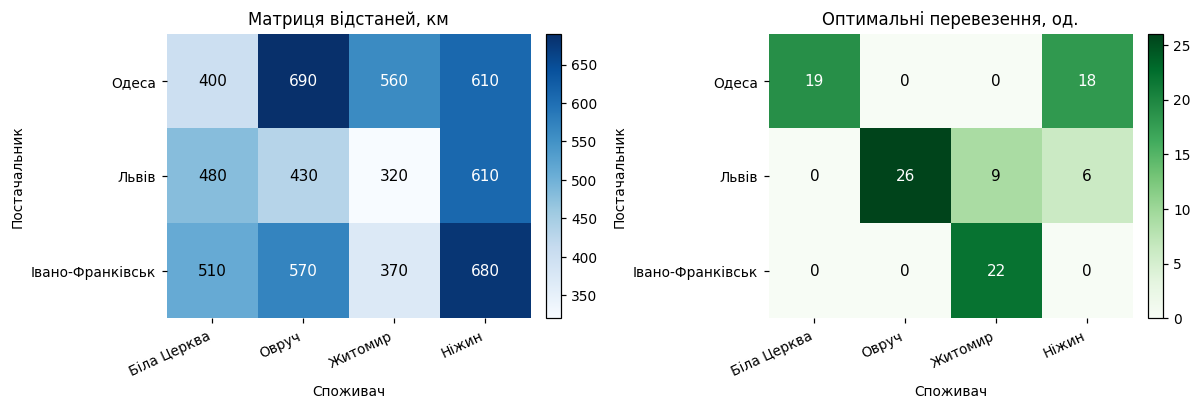

In [18]:
# ВАШ КОД
fig, осі = plt.subplots(1, 2, figsize=(11, 3.8))
дані = [(D, 'Матриця відстаней, км', 'Blues', '%.0f'),
        (план1, 'Оптимальні перевезення, од.', 'Greens', '%.0f')]
for ax, (M_, назва, кол, fmt) in zip(осі, дані):
    im = ax.imshow(M_, cmap=кол, aspect='auto')
    ax.set_xticks(range(n_т)); ax.set_xticklabels(споживачі, rotation=25, ha='right')
    ax.set_yticks(range(m_т)); ax.set_yticklabels(постачальники)
    ax.set_xlabel('Споживач'); ax.set_ylabel('Постачальник'); ax.set_title(назва)
    ax.spines[:].set_visible(False)
    норм = (M_ - M_.min()) / (M_.max() - M_.min())
    for i in range(m_т):
        for j in range(n_т):
            ax.text(j, i, fmt % M_[i, j], ha='center', va='center',
                    color='white' if норм[i, j] > 0.55 else 'black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'gemini'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Перевірила всі коди, які згенерував штучний інтелект, тексти по більшій мірі писала сама, проте могла взяти в ші ідею для напрямку'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Олійник Божена Орестівна
інструменти:                               gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Перевірила всі коди, які згенерував штучний інтелект, тексти по більшій мірі писала сама, проте могла взяти в ші ідею для напрямку


---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
